# Singapore Energy Demand Forecast
## ML Project: Predicting Electricity Consumption from Weather
> **Location:** Singapore (1.3521°N, 103.8198°E) | **Data:** Open-Meteo + EMA | **Period:** 2023–2025 (latest available EMA download)

This notebook implements a complete machine learning pipeline to predict Singapore's next-day electricity demand in MWh using historical weather conditions. The project trains two complementary models:
- **Regression Model**: Predicts exact MWh demand
- **Classification Model**: Predicts demand level (High/Medium/Low)

Both models support three prediction modes: historical dates (full dataset range), tomorrow (using live weather), and future dates (up to 16 days using forecast API).

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Visualization settings
import matplotlib
_styles = matplotlib.style.available
_pref = ['seaborn-v0_8-darkgrid', 'seaborn-darkgrid']
_style = next((s for s in _pref if s in _styles), 'ggplot')
plt.style.use(_style)
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Dynamic Singapore public holiday support
try:
    import holidays as holidays_lib
    _HAS_HOLIDAYS_LIB = True
except ImportError:
    _HAS_HOLIDAYS_LIB = False

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Step 2: Data Collection – Weather & Electricity Demand

### 2.1 Fetch Open-Meteo Weather Data

Singapore coordinates: Latitude 1.3521, Longitude 103.8198
- Daily variables: Temperature (max, min, mean), Humidity, Precipitation, Wind Speed, Apparent Temperature
- Period: 2023–2025 (weather range auto-matched to EMA demand data after load)

In [2]:
# Fetch Open-Meteo weather data for Singapore (2023–2025)
def fetch_weather_data(end_date):  # end_date required — pass demand_df['date'].max().strftime('%Y-%m-%d')
    """Fetch daily weather data from Open-Meteo API for Singapore.

    end_date is passed in so weather is always aligned to whatever
    period the EMA demand data covers (manual download, currently up to 2025).
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 1.3521,
        "longitude": 103.8198,
        "start_date": "2023-01-01",
        "end_date": end_date,  
        "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_max,precipitation_sum,wind_speed_10m_max,apparent_temperature_max",
        "timezone": "Asia/Singapore"
    }

    print("Fetching weather data from Open-Meteo...")
    try:
        response = requests.get(url, params=params, timeout=15)
        if response.status_code == 200:
            data = response.json()
            weather_df = pd.DataFrame({
                'date': pd.to_datetime(data['daily']['time']),
                'temp_max': data['daily']['temperature_2m_max'],
                'temp_min': data['daily']['temperature_2m_min'],
                'temp_mean': data['daily']['temperature_2m_mean'],
                'humidity_max': data['daily']['relative_humidity_2m_max'],
                'precipitation': data['daily']['precipitation_sum'],
                'wind_speed': data['daily']['wind_speed_10m_max'],
                'apparent_temp_max': data['daily']['apparent_temperature_max']
            })
            print(f"✓ Weather data fetched from API: {len(weather_df)} days")
            return weather_df
        else:
            print(f"⚠ API returned status {response.status_code}. Generating synthetic weather data...")
    except Exception as e:
        print(f"⚠ API call failed ({e}). Generating synthetic weather data...")

    # ── Synthetic fallback: realistic Singapore climate ──
    np.random.seed(42)
    dates = pd.date_range("2023-01-01", end_date, freq="D")  # end_date always supplied by Cell 2.3
    n = len(dates)
    doy = np.array([d.dayofyear for d in dates])

    # Singapore is near-equatorial; temp varies slightly with monsoon seasons
    # Use fractional year position so the seasonal cycle is correct across multiple years
    year_frac = np.array([(d - pd.Timestamp(str(d.year) + "-01-01")).days / 365.0 for d in dates])
    temp_mean_base = 27.5 + 1.5 * np.sin(2 * np.pi * (year_frac - 60/365))
    temp_mean = temp_mean_base + np.random.normal(0, 0.8, n)
    temp_max  = temp_mean + np.random.uniform(2.5, 4.5, n)
    temp_min  = temp_mean - np.random.uniform(2.0, 3.5, n)
    humidity_max = np.clip(85 + 5 * np.sin(2 * np.pi * (doy - 30) / 365) + np.random.normal(0, 4, n), 60, 100)
    precipitation = np.abs(np.random.exponential(3.5, n))
    wind_speed = np.abs(10 + np.random.normal(0, 3, n))
    apparent_temp_max = temp_max + 2.0 * humidity_max / 100 + np.random.normal(0, 0.5, n)

    weather_df = pd.DataFrame({
        'date': dates,
        'temp_max': np.round(temp_max, 1),
        'temp_min': np.round(temp_min, 1),
        'temp_mean': np.round(temp_mean, 1),
        'humidity_max': np.round(humidity_max, 1),
        'precipitation': np.round(precipitation, 1),
        'wind_speed': np.round(wind_speed, 1),
        'apparent_temp_max': np.round(apparent_temp_max, 1)
    })
    print(f"✓ Synthetic weather data generated: {len(weather_df)} days")
    return weather_df

# fetch_weather_data() is called in the merge cell (Cell 2.3) AFTER demand data
# is loaded, so end_date always matches the actual EMA download range.
print("✓ fetch_weather_data() defined — will be called after demand data loads.")


✓ fetch_weather_data() defined — will be called after demand data loads.


### 2.2 Load EMA Electricity Demand Data

The Energy Market Authority publishes half-hourly system demand data. We aggregate to daily MWh totals.

In [3]:
# Load EMA electricity demand data (with synthetic fallback if CSV not found)
import pathlib

candidate_paths = [
    pathlib.Path('ema_daily_demand.csv'),
    pathlib.Path('data') / 'ema_daily_demand.csv',
]

demand_file = next((path for path in candidate_paths if path.exists()), None)

def load_demand_data(path):
    demand_df = pd.read_csv(path, parse_dates=['date'])
    if 'demand_mwh' not in demand_df.columns:
        raise ValueError(
            "The demand CSV must contain a 'demand_mwh' column. "
            f"Found columns: {', '.join(demand_df.columns)}"
        )
    demand_df = demand_df[['date', 'demand_mwh']].copy()
    demand_df = demand_df.sort_values('date').reset_index(drop=True)
    if len(demand_df) < 31:
        raise ValueError(
            f"Loaded demand data has only {len(demand_df)} rows. "
            "The model requires at least 31 consecutive daily rows."
        )
    print(f"✓ Electricity demand data loaded: {len(demand_df)} days")
    return demand_df

def generate_synthetic_demand(weather_df):
    """Generate realistic Singapore daily electricity demand (MWh) from weather."""
    np.random.seed(42)
    dates = weather_df['date'].values  # always matches weather range including today
    temp_mean = weather_df['temp_mean'].values
    humidity_max = weather_df['humidity_max'].values
    n = len(dates)

    # Singapore system demand ~20,000–24,000 MWh/day; higher on hot/humid days
    base_demand = 21500
    temp_effect = 220 * (temp_mean - 27.5)          # +220 MWh per °C above 27.5
    humidity_effect = 30 * (humidity_max - 85)       # +30 MWh per % above 85
    # Weekend / holiday reduction
    dow = pd.DatetimeIndex(dates).dayofweek
    day_effect = np.where(dow >= 5, -800, 0)         # -800 MWh on weekends
    noise = np.random.normal(0, 150, n)
    demand = base_demand + temp_effect + humidity_effect + day_effect + noise
    demand_df = pd.DataFrame({'date': pd.DatetimeIndex(dates), 'demand_mwh': np.round(demand, 1)})
    return demand_df

if demand_file is None:
    print("⚠ EMA demand CSV not found. Synthetic demand will be generated after weather is")
    print("  aligned to the correct date range (Cell 2.3). Using placeholder for now...")
    demand_df = None  # placeholder; generated in Cell 2.3 after weather is aligned to 2025
    _using_synthetic_demand = True
    print("✓ Synthetic mode active — demand will be generated in Cell 2.3 with correct date range.")
else:
    _using_synthetic_demand = False
    print(f"Loading demand data from: {demand_file}")
    demand_df = load_demand_data(demand_file)
    print(f"\nDemand File Path: {demand_file.resolve()}")

print(f"\nDemand Data Shape: {demand_df.shape}")
print(demand_df.head(10))
print(f"Demand Statistics (MWh):\n{demand_df['demand_mwh'].describe()}")


Loading demand data from: ema_daily_demand.csv
✓ Electricity demand data loaded: 1071 days

Demand File Path: /workspaces/electricity-demand/ema_daily_demand.csv

Demand Data Shape: (1071, 2)
        date  demand_mwh
0 2023-01-02      143135
1 2023-01-03      155112
2 2023-01-04      154784
3 2023-01-05      156611
4 2023-01-06      158140
5 2023-01-07      150670
6 2023-01-08      148094
7 2023-01-09      160469
8 2023-01-10      161243
9 2023-01-11      158049
Demand Statistics (MWh):
count      1071.000000
mean     161831.220355
std        8081.351508
min      135278.000000
25%      156655.500000
50%      162871.000000
75%      167474.500000
max      180711.000000
Name: demand_mwh, dtype: float64


### 2.3 Join Weather and Demand Data

In [4]:
# Fetch weather aligned to the actual demand date range
# This ensures weather end_date matches EMA data (manual download, up to 2025)
demand_end = demand_df['date'].max().strftime('%Y-%m-%d')
print(f"Real EMA data ends: {demand_end}")

demand_start = '2023-01-01'
print(f"Fetching weather for {demand_start} → {demand_end}...")
weather_df = fetch_weather_data(end_date=demand_end)

# Merge weather and demand data on date
df = pd.merge(weather_df, demand_df, on='date', how='inner')

# Ensure date is in datetime format and sorted chronologically
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

if df.shape[0] < 31:
    raise ValueError(
        f"Merged dataset has only {df.shape[0]} rows after joining weather and demand data. "
        "This usually means the loaded demand CSV is incomplete or the notebook is using stale state. "
        "Please verify the demand file contains the full dataset and rerun this cell after restarting the kernel."
    )

print(f"✓ Datasets merged successfully")
print(f"\nFinal Dataset Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nDataset Overview:")
print(df.head(10))
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")

Real EMA data ends: 2026-01-04
Fetching weather for 2023-01-01 → 2026-01-04...
Fetching weather data from Open-Meteo...
✓ Weather data fetched from API: 1100 days
✓ Datasets merged successfully

Final Dataset Shape: (1071, 9)
Date range: 2023-01-02 00:00:00 to 2026-01-04 00:00:00

Dataset Overview:
        date  temp_max  temp_min  temp_mean  humidity_max  precipitation  \
0 2023-01-02      30.2      23.0       26.2            95            1.1   
1 2023-01-03      29.9      23.5       25.7            96            8.5   
2 2023-01-04      28.9      23.5       25.7            94            1.1   
3 2023-01-05      30.0      23.5       25.8            96            4.6   
4 2023-01-06      29.2      23.9       26.1            94            2.4   
5 2023-01-07      29.8      23.1       25.7            96            4.6   
6 2023-01-08      30.2      23.1       26.3            97            0.4   
7 2023-01-09      29.6      23.2       26.0            97            1.8   
8 2023-01-10    

## Step 3: Data Cleaning & Temporal Features

### 3.1 Add Singapore Public Holidays and Temporal Features

In [5]:
# Singapore Public Holidays for 2023 and 2024
singapore_holidays = {
    # 2023
    '2023-01-01': 'New Year Day',
    '2023-01-24': 'Chinese New Year',
    '2023-01-25': 'Chinese New Year Holiday',
    '2023-04-10': 'Hari Raya Puasa',
    '2023-05-01': 'Labour Day',
    '2023-05-26': 'Vesak Day',
    '2023-06-29': 'Hari Raya Haji',
    '2023-08-09': 'National Day',
    '2023-09-29': 'Deepavali',
    '2023-12-25': 'Christmas Day',
    # 2024
    '2024-01-01': 'New Year Day',
    '2024-02-10': 'Chinese New Year',
    '2024-02-11': 'Chinese New Year Holiday',
    '2024-03-29': 'Hari Raya Puasa',
    '2024-05-01': 'Labour Day',
    '2024-05-22': 'Vesak Day',
    '2024-06-17': 'Hari Raya Haji',
    '2024-08-09': 'National Day',
    '2024-10-31': 'Deepavali',
    '2024-12-25': 'Christmas Day',
    # 2025
    '2025-01-01': "New Year's Day",
    '2025-01-29': 'Chinese New Year',
    '2025-01-30': 'Chinese New Year (Day 2)',
    '2025-03-31': 'Hari Raya Puasa',
    '2025-04-18': 'Good Friday',
    '2025-05-01': 'Labour Day',
    '2025-05-12': 'Vesak Day',
    '2025-06-07': 'Hari Raya Haji',
    '2025-08-09': 'National Day',
    '2025-10-20': 'Deepavali',
    '2025-12-25': 'Christmas Day',
}

# ── Dynamic holiday lookup (uses `holidays` lib when available) ──
if _HAS_HOLIDAYS_LIB:
    sg_years = df['date'].dt.year.unique().tolist()
    sg_holiday_dates = set()
    for yr in sg_years:
        sg_holiday_dates.update(str(d) for d in holidays_lib.Singapore(years=yr).keys())
else:
    sg_holiday_dates = set(singapore_holidays.keys())

# Add temporal and holiday features
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_holiday'] = df['date'].dt.strftime('%Y-%m-%d').isin(sg_holiday_dates).astype(int)
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week

print("✓ Temporal and holiday features added")
print(f"\nHolidays in dataset: {df['is_holiday'].sum()}")
print(f"Weekend days: {df['is_weekend'].sum()}")
print(f"\nFeature columns: {df.columns.tolist()}")

✓ Temporal and holiday features added

Holidays in dataset: 38
Weekend days: 306

Feature columns: ['date', 'temp_max', 'temp_min', 'temp_mean', 'humidity_max', 'precipitation', 'wind_speed', 'apparent_temp_max', 'demand_mwh', 'is_weekend', 'is_holiday', 'day_of_week', 'month', 'day_of_year', 'week_of_year']


## Step 4: Exploratory Data Analysis (EDA)

### 4.1 Time Series and Seasonal Patterns

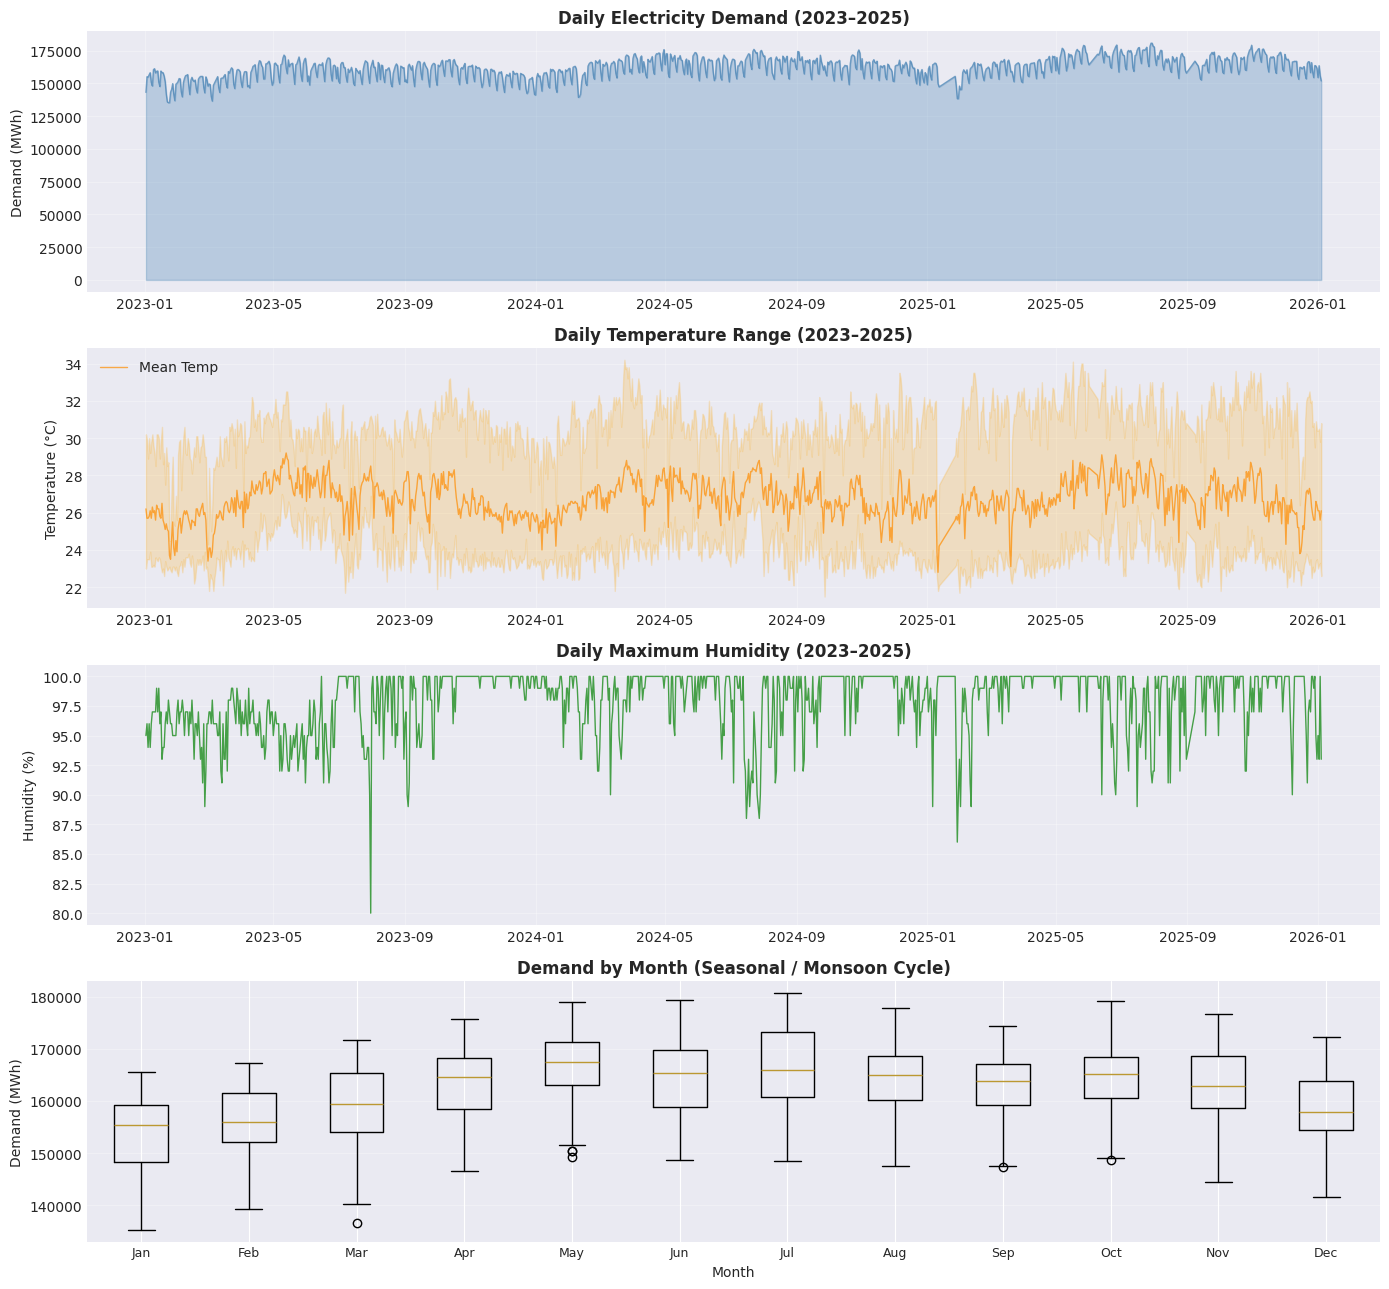

✓ Time series visualizations created


In [11]:
# Time series plot of demand
fig, axes = plt.subplots(4, 1, figsize=(14, 13))

# Demand over time
axes[0].plot(df['date'], df['demand_mwh'], linewidth=1, alpha=0.7, color='steelblue')
axes[0].fill_between(df['date'], df['demand_mwh'], alpha=0.3, color='steelblue')
axes[0].set_title('Daily Electricity Demand (2023–2025)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Demand (MWh)')
axes[0].grid(True, alpha=0.3)

# Temperature over time
axes[1].plot(df['date'], df['temp_mean'], label='Mean Temp', linewidth=1, alpha=0.7, color='darkorange')
axes[1].fill_between(df['date'], df['temp_max'], df['temp_min'], alpha=0.2, color='orange')
axes[1].set_title('Daily Temperature Range (2023–2025)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Humidity over time
axes[2].plot(df['date'], df['humidity_max'], linewidth=1, alpha=0.7, color='green')
axes[2].set_title('Daily Maximum Humidity (2023–2025)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Humidity (%)')
axes[2].grid(True, alpha=0.3)

# Demand by month — seasonal / monsoon cycle
month_groups = [df[df['month'] == m]['demand_mwh'] for m in range(1, 13)]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[3].boxplot(month_groups, labels=month_labels)

axes[3].set_title('Demand by Month (Seasonal / Monsoon Cycle)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Demand (MWh)')
axes[3].set_xlabel('Month')
axes[3].tick_params(axis='x', labelsize=9)
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Time series visualizations created")

### 4.2 Correlation Analysis & Weather-Demand Relationship

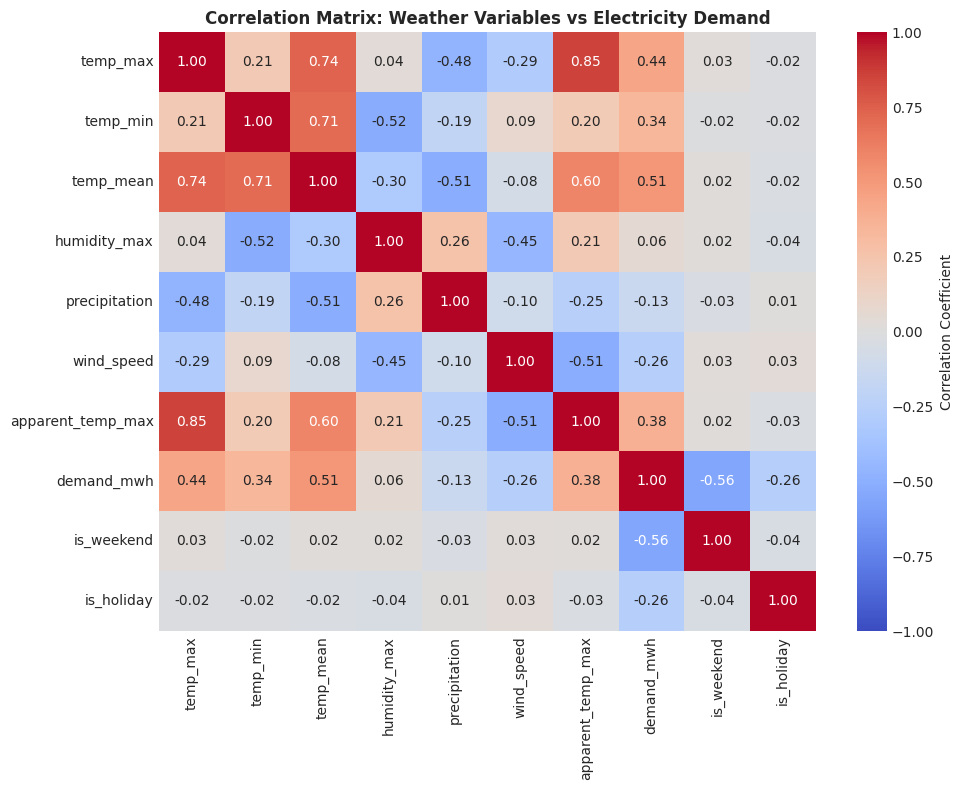

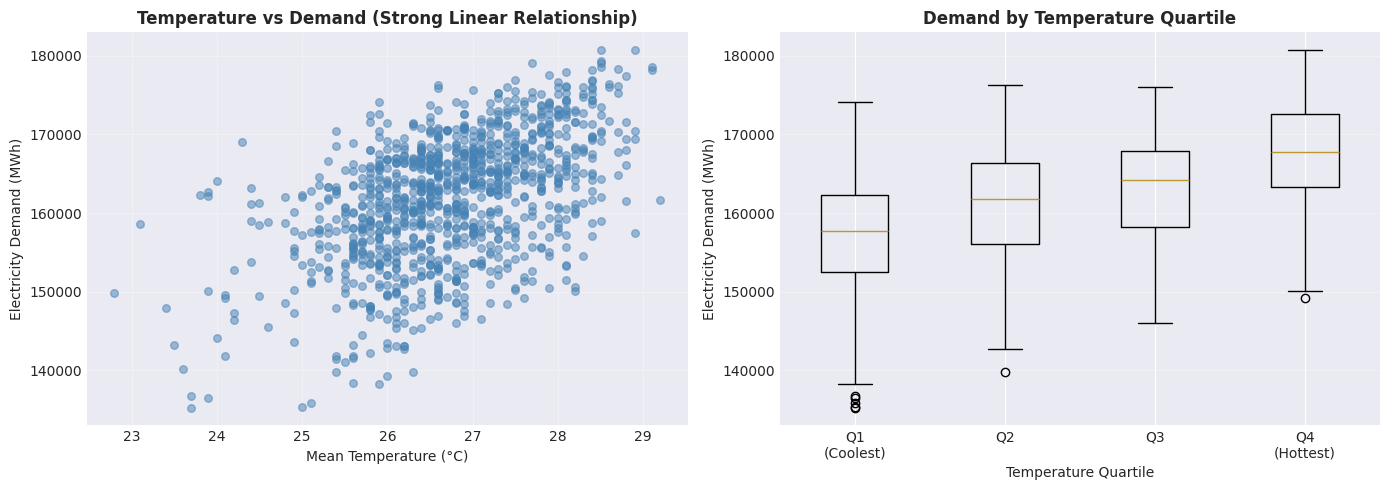

✓ Correlation and scatter plot analysis completed


In [13]:

# Correlation heatmap
numeric_cols = ['temp_max', 'temp_min', 'temp_mean', 'humidity_max', 'precipitation', 
                'wind_speed', 'apparent_temp_max', 'demand_mwh', 'is_weekend', 'is_holiday']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation Coefficient'}, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Weather Variables vs Electricity Demand', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Temperature vs Demand (strongest continuous predictor)
axes[0].scatter(df['temp_mean'], df['demand_mwh'], alpha=0.5, s=30, color='steelblue')
axes[0].set_xlabel('Mean Temperature (°C)')
axes[0].set_ylabel('Electricity Demand (MWh)')
axes[0].set_title('Temperature vs Demand (Strong Linear Relationship)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Boxplot: Demand by temperature quartile
# Shows how demand rises step-wise as temperature increases (AC-driven effect)
df['temp_quartile'] = pd.qcut(df['temp_mean'], q=4,
                               labels=['Q1\n(Coolest)', 'Q2', 'Q3', 'Q4\n(Hottest)'])
temp_q_groups = [df[df['temp_quartile'] == q]['demand_mwh']
                 for q in ['Q1\n(Coolest)', 'Q2', 'Q3', 'Q4\n(Hottest)']]
axes[1].boxplot(temp_q_groups, labels=['Q1\n(Coolest)', 'Q2', 'Q3', 'Q4\n(Hottest)'])
axes[1].set_xlabel('Temperature Quartile')
axes[1].set_ylabel('Electricity Demand (MWh)')
axes[1].set_title('Demand by Temperature Quartile', fontweight='bold')
# axes[1].set_title('Demand by Temperature Quartile\n(Step-wise AC Effect)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Correlation and scatter plot analysis completed")


### 4.3 Demand by Day Type (Weekday vs Weekend vs Holiday)

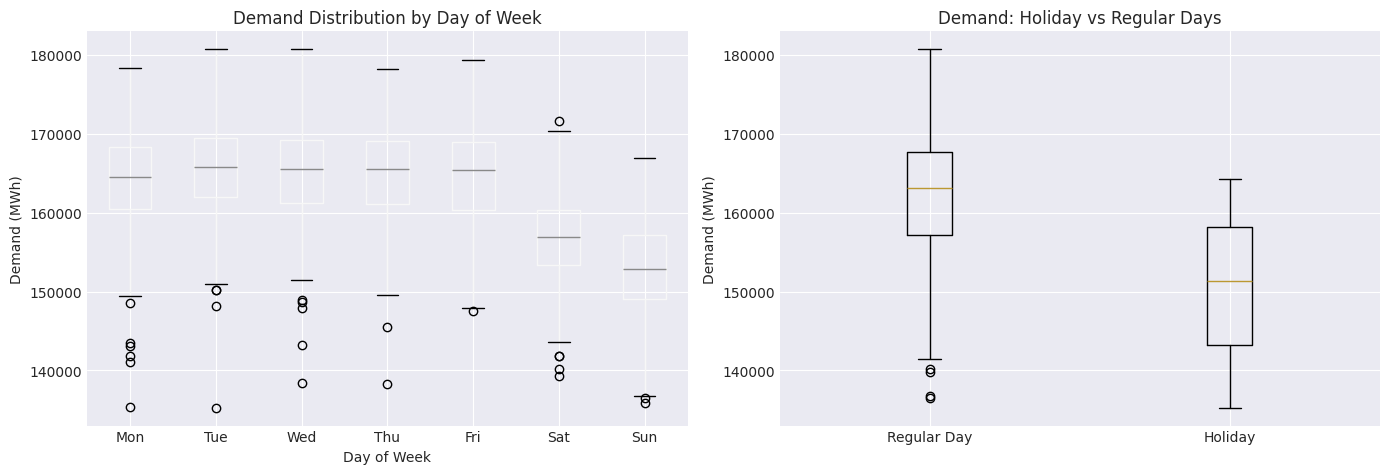


DEMAND STATISTICS BY DAY TYPE

By Day of Week:
                mean      std     min     max
day_name                                     
Friday     164648.22  6612.93  147500  179287
Monday     163760.21  7369.37  135319  178290
Saturday   156635.73  6120.29  139332  171569
Sunday     152749.63  6063.09  135867  166932
Thursday   164937.32  6562.30  138319  178234
Tuesday    165242.75  6678.32  135278  180694
Wednesday  164844.68  6879.35  138354  180711

Holiday vs Regular Days:
                 mean      std     min     max
is_holiday                                    
0           162240.90  7762.18  136493  180711
1           150694.37  8720.64  135278  164320


In [8]:
# Create day type labels
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['day_name'] = df['day_of_week'].map(day_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by day of week
df.boxplot(column='demand_mwh', by='day_of_week', ax=axes[0])
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Demand (MWh)')
axes[0].set_title('Demand Distribution by Day of Week')

# Robustly set tick positions to match 7 day labels
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
tick_positions = list(range(1, len(day_labels) + 1))
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(day_labels)
plt.sca(axes[0])
plt.xticks(tick_positions, day_labels)

# Demand by holiday status
holiday_data = []
holiday_labels = []
for is_hol in [0, 1]:
    holiday_data.append(df[df['is_holiday'] == is_hol]['demand_mwh'])
    holiday_labels.append('Holiday' if is_hol == 1 else 'Regular Day')

axes[1].boxplot(holiday_data, labels=holiday_labels)
axes[1].set_ylabel('Demand (MWh)')
axes[1].set_title('Demand: Holiday vs Regular Days')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'='*50}")
print(f"DEMAND STATISTICS BY DAY TYPE")
print(f"{'='*50}")
print(f"\nBy Day of Week:")
print(df.groupby('day_name')['demand_mwh'].agg(['mean', 'std', 'min', 'max']).round(2))
print(f"\nHoliday vs Regular Days:")
print(df.groupby('is_holiday')['demand_mwh'].agg(['mean', 'std', 'min', 'max']).round(2))

## Step 5: Feature Engineering - Lag & Rolling Features

### 5.1 Create Lag Features (NO FUTURE DATA LEAKAGE)

In [9]:
# Create lag features for demand
df['demand_lag_1'] = df['demand_mwh'].shift(1)  # Yesterday's demand
df['demand_lag_7'] = df['demand_mwh'].shift(7)  # Same day last week

# Create lag features for temperature
df['temp_mean_lag_1'] = df['temp_mean'].shift(1)  # Yesterday's temperature
df['temp_max_lag_1'] = df['temp_max'].shift(1)

# Create rolling average features
# IMPORTANT: shift(1) BEFORE rolling to prevent data leakage — rolling window
# must NOT include the current day's actual demand (which is the prediction target)
df['demand_rolling_7'] = df['demand_mwh'].shift(1).rolling(window=7, min_periods=7).mean()
df['demand_rolling_30'] = df['demand_mwh'].shift(1).rolling(window=30, min_periods=30).mean()
df['temp_mean_rolling_3'] = df['temp_mean'].shift(1).rolling(window=3, min_periods=3).mean()
df['humidity_rolling_3'] = df['humidity_max'].shift(1).rolling(window=3, min_periods=3).mean()

# Create interaction features
df['temp_humidity_interaction'] = df['temp_mean'] * df['humidity_max'] / 100

print("✓ Lag and rolling features created (with shift(1) to prevent leakage)")
print(f"\nNew features added:")
print(f"  - Lag features: demand_lag_1, demand_lag_7, temp_mean_lag_1, temp_max_lag_1")
print(f"  - Rolling features: demand_rolling_7, demand_rolling_30, temp_mean_rolling_3, humidity_rolling_3")
print(f"    (all rolling features use shift(1) — no current-day leakage)")
print(f"  - Interaction: temp_humidity_interaction")
print(f"\nDataset shape after feature engineering: {df.shape}")
print(f"\nFeature columns:\n{df.columns.tolist()}")

✓ Lag and rolling features created (with shift(1) to prevent leakage)

New features added:
  - Lag features: demand_lag_1, demand_lag_7, temp_mean_lag_1, temp_max_lag_1
  - Rolling features: demand_rolling_7, demand_rolling_30, temp_mean_rolling_3, humidity_rolling_3
    (all rolling features use shift(1) — no current-day leakage)
  - Interaction: temp_humidity_interaction

Dataset shape after feature engineering: (1071, 25)

Feature columns:
['date', 'temp_max', 'temp_min', 'temp_mean', 'humidity_max', 'precipitation', 'wind_speed', 'apparent_temp_max', 'demand_mwh', 'is_weekend', 'is_holiday', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'day_name', 'demand_lag_1', 'demand_lag_7', 'temp_mean_lag_1', 'temp_max_lag_1', 'demand_rolling_7', 'demand_rolling_30', 'temp_mean_rolling_3', 'humidity_rolling_3', 'temp_humidity_interaction']


### 5.2 Prepare Data for Modeling

In [10]:
# Remove rows with NaN values from lag and rolling features (first 30 days)
df_clean = df.dropna().reset_index(drop=True)

print(f"Original dataset: {df.shape[0]} rows")
print(f"After removing NaN (lag/rolling): {df_clean.shape[0]} rows")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

# Select features for modeling
feature_cols = [
    # Weather features
    'temp_max', 'temp_min', 'temp_mean', 'humidity_max', 'precipitation', 'wind_speed', 'apparent_temp_max',
    # Lag features
    'demand_lag_1', 'demand_lag_7', 'temp_mean_lag_1',
    # Rolling features
    'demand_rolling_7', 'demand_rolling_30', 'temp_mean_rolling_3', 'humidity_rolling_3',
    # Temporal features
    'is_weekend', 'is_holiday', 'month', 'day_of_year', 'week_of_year',
    # Interaction features
    'temp_humidity_interaction'
]

target_col = 'demand_mwh'

X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

print(f"\n✓ Features selected: {len(feature_cols)} features")
print(f"✓ Target variable: {target_col}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nMissing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")

Original dataset: 1071 rows
After removing NaN (lag/rolling): 1041 rows
Rows removed: 30

✓ Features selected: 20 features
✓ Target variable: demand_mwh

Feature columns:
   1. temp_max
   2. temp_min
   3. temp_mean
   4. humidity_max
   5. precipitation
   6. wind_speed
   7. apparent_temp_max
   8. demand_lag_1
   9. demand_lag_7
  10. temp_mean_lag_1
  11. demand_rolling_7
  12. demand_rolling_30
  13. temp_mean_rolling_3
  14. humidity_rolling_3
  15. is_weekend
  16. is_holiday
  17. month
  18. day_of_year
  19. week_of_year
  20. temp_humidity_interaction

X shape: (1041, 20)
y shape: (1041,)

Missing values in X: 0
Missing values in y: 0


## Step 6: Train/Test Split & Baseline Forecast

### 6.1 Chronological Split (80% train, 20% test)

In [11]:
# Chronological split: first 80% for training, last 20% for testing
split_idx = int(len(X) * 0.80)

if len(X) == 0:
    raise ValueError(
        "No feature rows are available after preprocessing. "
        "Please rerun the data loading and feature engineering cells to ensure `df_clean` contains valid rows."
    )

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Store dates for reference
dates_train = df_clean['date'].iloc[:split_idx]
dates_test = df_clean['date'].iloc[split_idx:]

print(f"✓ Chronological Train/Test Split")
print(f"\nTotal feature rows: {len(X)}")
print(f"Split index: {split_idx}")
print(f"\nTrain set:")
print(f"  - Samples: {X_train.shape[0]}")
print(f"  - Date range: {dates_train.min() if X_train.shape[0] > 0 else 'N/A'} to {dates_train.max() if X_train.shape[0] > 0 else 'N/A'}")
print(f"\nTest set:")
print(f"  - Samples: {X_test.shape[0]}")
print(f"  - Date range: {dates_test.min() if X_test.shape[0] > 0 else 'N/A'} to {dates_test.max() if X_test.shape[0] > 0 else 'N/A'}")
print(f"\nTrain/test ratio: {X_train.shape[0]}/{X_test.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}% train, {X_test.shape[0]/len(X)*100:.1f}% test)")

✓ Chronological Train/Test Split

Total feature rows: 1041
Split index: 832

Train set:
  - Samples: 832
  - Date range: 2023-02-01 00:00:00 to 2025-05-26 00:00:00

Test set:
  - Samples: 209
  - Date range: 2025-05-27 00:00:00 to 2026-01-04 00:00:00

Train/test ratio: 832/209 (79.9% train, 20.1% test)


### 6.2 Establish Naive Baseline (Lag-1 Forecast)

In [12]:
# Baseline: predict today's demand equals yesterday's demand (lag-1)
baseline_pred_test = X_test['demand_lag_1'].values

# Compute baseline metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred_test))
baseline_r2 = r2_score(y_test, baseline_pred_test)

print("="*60)
print("BASELINE MODEL: Predict today = yesterday's demand (LAG-1)")
print("="*60)
print(f"\nBaseline Performance on Test Set:")
print(f"  MAE:  {baseline_mae:8.2f} MWh")
print(f"  RMSE: {baseline_rmse:8.2f} MWh")
print(f"  R²:   {baseline_r2:8.4f}")
print(f"\nThis baseline will be compared against ML models.")

BASELINE MODEL: Predict today = yesterday's demand (LAG-1)

Baseline Performance on Test Set:
  MAE:   4201.75 MWh
  RMSE:  5730.90 MWh
  R²:     0.2395

This baseline will be compared against ML models.


## Step 7: Model Training – Regression & Classification

### 7.1 Standardize Features

In [13]:
# Standardize features (critical for Linear Regression)
scaler = StandardScaler()

# Guard: ensure training data exists before scaling
if X_train.shape[0] == 0:
    print(f"DEBUG: Total feature rows: {len(X)}")
    print(f"DEBUG: df_clean shape: {df_clean.shape}")
    print(f"DEBUG: X shape: {X.shape}")
    print(f"DEBUG: split_idx = {split_idx}")
    raise ValueError(
        "Empty training set: `X_train` has 0 rows.\n"
        "This means the chronological split allocated all rows to the test set because the dataset is too small or because preprocessing was not rerun after data changes.\n"
        "Please restart the notebook kernel and run the cells from Step 2 through Step 7 in order.\n"
        "If you are using a local demand CSV, make sure it contains at least 31 consecutive daily values for a valid rolling window."    )

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized using StandardScaler")
print(f"\nScaled data statistics:")
print(f"  Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"  Test mean:  {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

✓ Features standardized using StandardScaler

Scaled data statistics:
  Train mean: -0.000000, std: 1.000000
  Test mean:  0.430945, std: 1.034767


### 7.2 Task 1 – Regression Models (Exact MWh Prediction)

In [14]:
# Ensure scaler has been run (guard against out-of-order execution)
if 'X_train_scaled' not in globals() or 'X_test_scaled' not in globals():
    print("⚠ Scaler not found — running StandardScaler now...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✓ Features scaled.")

# Helper: Mean Absolute Percentage Error
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ── Linear Regression ──
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

lr_train_mae = mean_absolute_error(y_train, y_train_pred_lr)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
lr_train_r2 = r2_score(y_train, y_train_pred_lr)

lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
lr_test_r2 = r2_score(y_test, y_test_pred_lr)
lr_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_lr)

print(f"✓ Linear Regression trained")

# ── Random Forest Regressor with Hyperparameter Tuning ──
print("Training Random Forest Regressor (with RandomizedSearchCV)...")
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, param_dist, n_iter=20, cv=tscv,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rf_train_r2 = r2_score(y_train, y_train_pred_rf)

rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_rf)

print(f"✓ Random Forest Regressor trained")
print(f"  Best params: {rf_search.best_params_}")

# ── Cross-Validation Scores ──
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
cv_mae_mean = -cv_scores.mean()
cv_mae_std = cv_scores.std()

print(f"\n  TimeSeriesSplit CV (5-fold) MAE: {cv_mae_mean:.2f} ± {cv_mae_std:.2f} MWh")

# ── Baseline MAPE ──
baseline_mape = mean_absolute_percentage_error(y_test, baseline_pred_test)

# Display results
SEP  = "=" * 85
LINE = "-" * 85
print("\n" + SEP)
print(f"{'REGRESSION MODEL COMPARISON':^85}")
print(SEP)
print(f"{'Model':<25} {'MAE (MWh)':<14} {'RMSE (MWh)':<14} {'MAPE (%)':<12} {'R² Score':<10}")
print(LINE)
print(f"{'Baseline (Lag-1)':<25} {baseline_mae:<14.2f} {baseline_rmse:<14.2f} {baseline_mape:<12.2f} {baseline_r2:<10.4f}")
print(f"{'Linear Regression':<25} {lr_test_mae:<14.2f} {lr_test_rmse:<14.2f} {lr_test_mape:<12.2f} {lr_test_r2:<10.4f}")
print(f"{'Random Forest':<25} {rf_test_mae:<14.2f} {rf_test_rmse:<14.2f} {rf_test_mape:<12.2f} {rf_test_r2:<10.4f}")
print(SEP)

best_reg = 'Linear Regression' if lr_test_r2 > rf_test_r2 else 'Random Forest'
best_test_mae = min(lr_test_mae, rf_test_mae)
print(f"\n✓ Best regression model: {best_reg}")
print(f"  Improvement over baseline (MAE): {(baseline_mae - best_test_mae):.2f} MWh ({(baseline_mae - best_test_mae)/baseline_mae*100:.1f}%)")
print(f"  Cross-validated MAE (train): {cv_mae_mean:.2f} ± {cv_mae_std:.2f} MWh")

Training Linear Regression...
✓ Linear Regression trained
Training Random Forest Regressor (with RandomizedSearchCV)...
✓ Random Forest Regressor trained
  Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}

  TimeSeriesSplit CV (5-fold) MAE: 2380.20 ± 646.50 MWh

                             REGRESSION MODEL COMPARISON                             
Model                     MAE (MWh)      RMSE (MWh)     MAPE (%)     R² Score  
-------------------------------------------------------------------------------------
Baseline (Lag-1)          4201.75        5730.90        2.53         0.2395    
Linear Regression         1545.62        2028.21        0.92         0.9047    
Random Forest             1955.59        2462.47        1.15         0.8596    

✓ Best regression model: Linear Regression
  Improvement over baseline (MAE): 2656.13 MWh (63.2%)
  Cross-validated MAE (train): 2380.20 ± 646.50 MWh


### 7.2b Feature Importance Analysis

Understanding which features drive predictions helps validate that the model learned meaningful patterns (weather signals) rather than simply memorizing lag values.

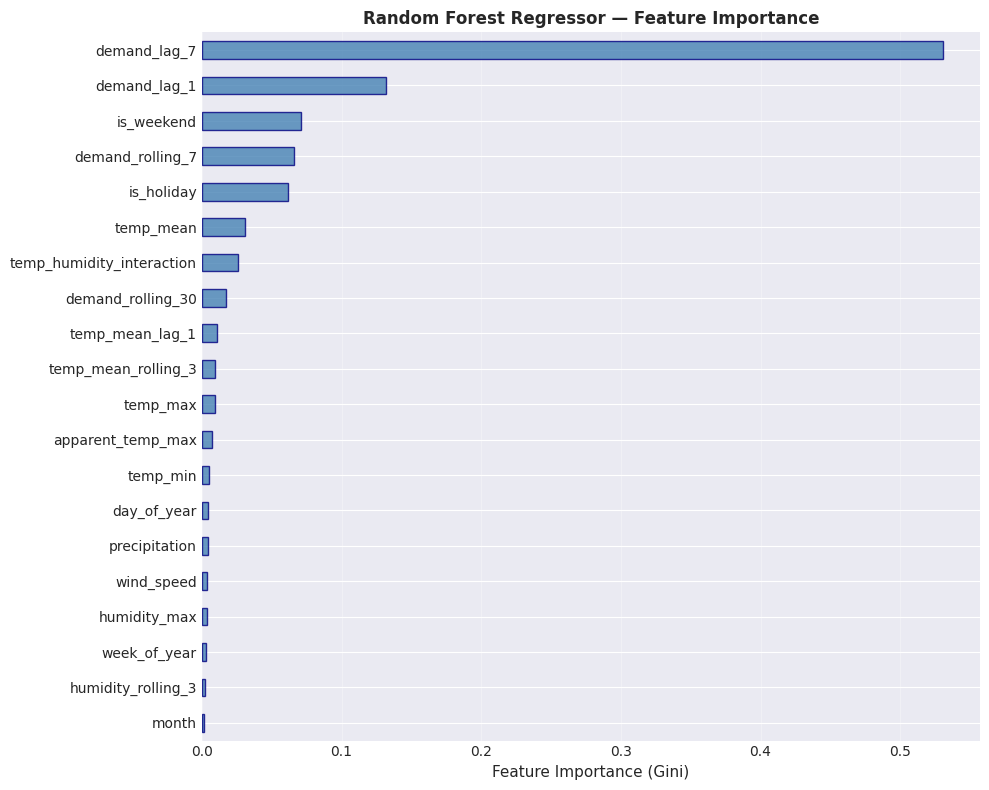


Top-5 most important features:
  1. demand_lag_7                   0.5306
  2. demand_lag_1                   0.1317
  3. is_weekend                     0.0711
  4. demand_rolling_7               0.0659
  5. is_holiday                     0.0618

  Lag/rolling demand importance: 0.745 (74.5%)
  Weather features importance:   0.087 (8.7%)
  ⚠ Model heavily relies on lag features — weather signal is secondary.


In [15]:
# Feature importance from Random Forest Regressor
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='navy', alpha=0.8)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Random Forest Regressor — Feature Importance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Highlight top-5 features
print("\nTop-5 most important features:")
top5 = importances.sort_values(ascending=False).head(5)
for i, (feat, imp) in enumerate(top5.items(), 1):
    print(f"  {i}. {feat:<30s} {imp:.4f}")

# Flag if lag/rolling features dominate
lag_rolling_features = ['demand_lag_1', 'demand_lag_7', 'demand_rolling_7', 'demand_rolling_30']
lag_importance = importances[importances.index.isin(lag_rolling_features)].sum()
weather_features = ['temp_max', 'temp_min', 'temp_mean', 'humidity_max', 'precipitation',
                    'wind_speed', 'apparent_temp_max', 'temp_mean_lag_1', 'temp_mean_rolling_3', 'humidity_rolling_3']
weather_importance = importances[importances.index.isin(weather_features)].sum()

print(f"\n  Lag/rolling demand importance: {lag_importance:.3f} ({lag_importance*100:.1f}%)")
print(f"  Weather features importance:   {weather_importance:.3f} ({weather_importance*100:.1f}%)")
if lag_importance > 0.7:
    print("  ⚠ Model heavily relies on lag features — weather signal is secondary.")

### 7.3 Task 2 – Classification Models (High/Medium/Low Demand)

In [16]:
# Ensure the training split and scaling step have completed successfully
if X_train.shape[0] == 0 or len(y_train) == 0:
    raise ValueError(
        "Cannot train classification models because the training set is empty. "
        "Please restart the kernel and rerun the notebook from Step 2 through Step 7."
    )

if 'X_train_scaled' not in globals() or 'X_test_scaled' not in globals():
    raise ValueError(
        "Feature scaling has not been completed. "
        "Run the standardization cell in Step 7.1 before training classification models."
    )

if y_train.isnull().any() or y_test.isnull().any():
    raise ValueError(
        "Target data contains missing values. "
        "Check the preprocessing steps and ensure the dataset was loaded correctly."
    )

# Create classification target using exact tertiles (33%/67%) on training set
# so each class has equal frequency IN THE TRAINING SET
percentile_33 = y_train.quantile(1/3)
percentile_67 = y_train.quantile(2/3)

def demand_to_class(demand):
    if demand <= percentile_33:
        return 0  # Low
    elif demand <= percentile_67:
        return 1  # Medium
    else:
        return 2  # High

y_train_class = y_train.apply(demand_to_class).astype(int)
y_test_class  = y_test.apply(demand_to_class).astype(int)

class_names = ['Low', 'Medium', 'High']
print(f"Classification thresholds (from training set):")
print(f"  Low:    0 – {percentile_33:.0f} MWh")
print(f"  Medium: {percentile_33:.0f} – {percentile_67:.0f} MWh")
print(f"  High:   {percentile_67:.0f}+ MWh")

# Training set class distribution
train_counts = y_train_class.value_counts().sort_index()
print(f"\nTraining set class counts:")
for cls_idx, name in enumerate(class_names):
    n = int(train_counts[cls_idx]) if cls_idx in train_counts.index else 0
    print(f"  {name}: {n} ({n/len(y_train_class)*100:.1f}%)")

# Test set distribution (may differ — that's normal for time-series)
test_counts = y_test_class.value_counts().sort_index()
print(f"\nTest set class counts:")
for cls_idx, name in enumerate(class_names):
    n = int(test_counts[cls_idx]) if cls_idx in test_counts.index else 0
    print(f"  {name}: {n} ({n/len(y_test_class)*100:.1f}%)")


# Logistic Regression Classifier
print("\nTraining Logistic Regression...")
lr_class = LogisticRegression(max_iter=1000, random_state=42)
lr_class.fit(X_train_scaled, y_train_class)
y_train_pred_lr_class = lr_class.predict(X_train_scaled)
y_test_pred_lr_class = lr_class.predict(X_test_scaled)
y_test_prob_lr_class = lr_class.predict_proba(X_test_scaled)

lr_class_train_acc = accuracy_score(y_train_class, y_train_pred_lr_class)
lr_class_test_acc = accuracy_score(y_test_class, y_test_pred_lr_class)

print(f"✓ Logistic Regression trained")

# Random Forest Classifier
print("Training Random Forest Classifier...")
rf_class = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_class.fit(X_train, y_train_class)
y_train_pred_rf_class = rf_class.predict(X_train)
y_test_pred_rf_class = rf_class.predict(X_test)
y_test_prob_rf_class = rf_class.predict_proba(X_test)

rf_class_train_acc = accuracy_score(y_train_class, y_train_pred_rf_class)
rf_class_test_acc = accuracy_score(y_test_class, y_test_pred_rf_class)

print(f"✓ Random Forest Classifier trained")

# Display classification results

# Pre-compute F1 scores to avoid silent failures from inline function calls in f-strings
lr_cls_f1  = f1_score(y_test_class, y_test_pred_lr_class, average='macro')
rf_cls_f1  = f1_score(y_test_class, y_test_pred_rf_class, average='macro')

SEP  = "=" * 63
LINE = "-" * 63
print("\n" + SEP)
print(f"{'CLASSIFICATION MODEL COMPARISON (Test Set)':^63}")
print(SEP)
print(f"{'Model':<25} {'Accuracy':<18} {'Macro F1 Score':<15}")
print(LINE)
print(f"{'Logistic Regression':<25} {lr_class_test_acc:<18.4f} {lr_cls_f1:<15.4f}")
print(f"{'Random Forest':<25} {rf_class_test_acc:<18.4f} {rf_cls_f1:<15.4f}")
print(SEP)
best_cls = 'Logistic Regression' if lr_class_test_acc > rf_class_test_acc else 'Random Forest'
print(f"\n✓ Best classification model: {best_cls}")

Classification thresholds (from training set):
  Low:    0 – 157873 MWh
  Medium: 157873 – 164803 MWh
  High:   164803+ MWh

Training set class counts:
  Low: 278 (33.4%)
  Medium: 277 (33.3%)
  High: 277 (33.3%)

Test set class counts:
  Low: 15 (7.2%)
  Medium: 50 (23.9%)
  High: 144 (68.9%)

Training Logistic Regression...
✓ Logistic Regression trained
Training Random Forest Classifier...


✓ Random Forest Classifier trained

          CLASSIFICATION MODEL COMPARISON (Test Set)           
Model                     Accuracy           Macro F1 Score 
---------------------------------------------------------------
Logistic Regression       0.8804             0.7913         
Random Forest             0.8565             0.7657         

✓ Best classification model: Logistic Regression


## Step 8: Model Evaluation & Visualization

### 8.1 Regression Model Predictions vs Actual

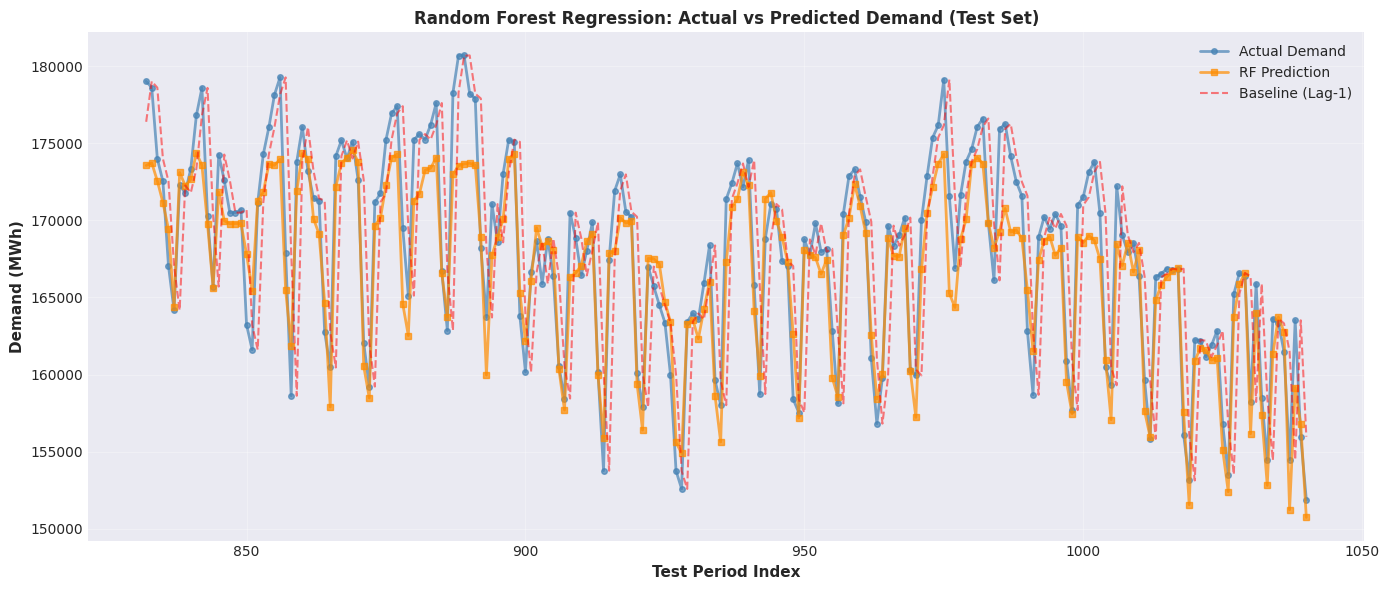

✓ Regression predictions visualized

Test set performance:
  Actual demand range: 151861 - 180711 MWh
  Predicted range: 150722 - 174551 MWh


In [17]:
# Plot actual vs predicted on test set (use best model: Random Forest)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_test.index, y_test.values, 'o-', linewidth=2, markersize=4, label='Actual Demand', color='steelblue', alpha=0.7)
ax.plot(dates_test.index, y_test_pred_rf, 's-', linewidth=2, markersize=4, label='RF Prediction', color='darkorange', alpha=0.7)
ax.plot(dates_test.index, baseline_pred_test, '--', linewidth=1.5, label='Baseline (Lag-1)', color='red', alpha=0.5)

ax.set_xlabel('Test Period Index', fontsize=11, fontweight='bold')
ax.set_ylabel('Demand (MWh)', fontsize=11, fontweight='bold')
ax.set_title('Random Forest Regression: Actual vs Predicted Demand (Test Set)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Regression predictions visualized")
print(f"\nTest set performance:")
print(f"  Actual demand range: {y_test.min():.0f} - {y_test.max():.0f} MWh")
print(f"  Predicted range: {y_test_pred_rf.min():.0f} - {y_test_pred_rf.max():.0f} MWh")

### 8.2 Classification Confusion Matrix & Metrics


CLASSIFICATION METRICS (Random Forest on Test Set)

Accuracy: 0.8565
Macro F1 Score: 0.7657

Detailed Classification Report:
              precision    recall  f1-score   support

         Low       0.52      0.93      0.67        15
      Medium       0.72      0.66      0.69        50
        High       0.97      0.92      0.94       144

    accuracy                           0.86       209
   macro avg       0.74      0.84      0.77       209
weighted avg       0.88      0.86      0.86       209



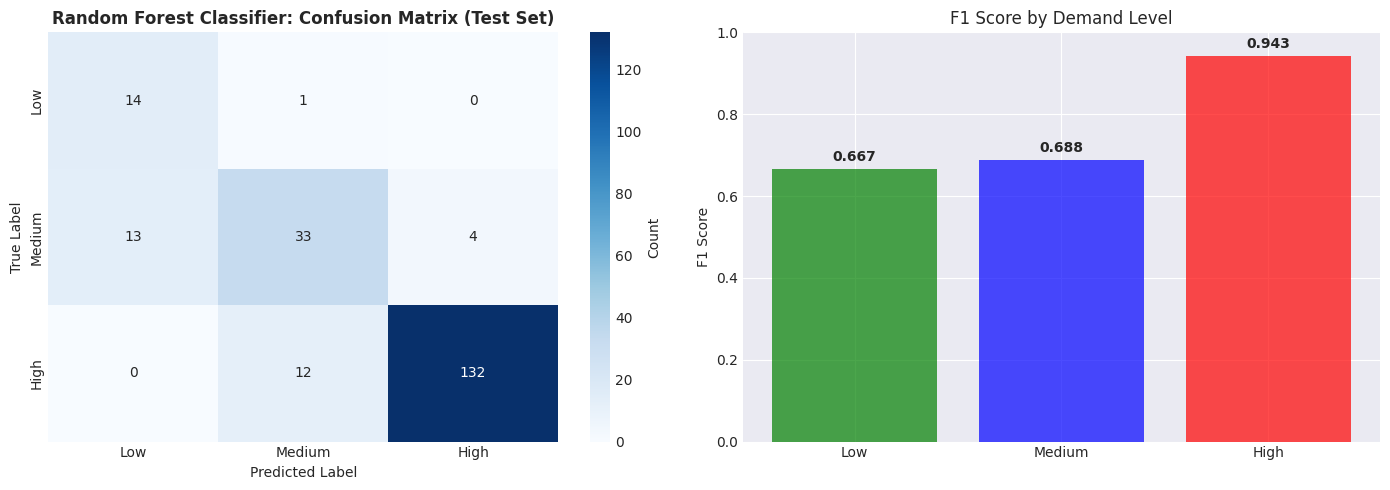

✓ Classification metrics visualized


In [18]:
# Confusion matrix for best classifier (Random Forest)
labels = [0, 1, 2]
cm = confusion_matrix(y_test_class, y_test_pred_rf_class, labels=labels)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    cbar_kws={'label': 'Count'}
)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Random Forest Classifier: Confusion Matrix (Test Set)', fontweight='bold')

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION METRICS (Random Forest on Test Set)")
print("="*70)
print(f"\nAccuracy: {rf_class_test_acc:.4f}")
print(f"Macro F1 Score: {f1_score(y_test_class, y_test_pred_rf_class, average='macro'):.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(
    y_test_class,
    y_test_pred_rf_class,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# F1 scores per class
f1_scores = f1_score(y_test_class, y_test_pred_rf_class, labels=labels, average=None, zero_division=0)
axes[1].bar(class_names, f1_scores, color=['green', 'blue', 'red'], alpha=0.7)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score by Demand Level')
axes[1].set_ylim([0, 1])
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Classification metrics visualized")

### 8.3 Residual Analysis — Prediction Errors Over Time

Checking whether errors are random (good) or show systematic bias during certain periods (e.g., monsoon season, holidays).

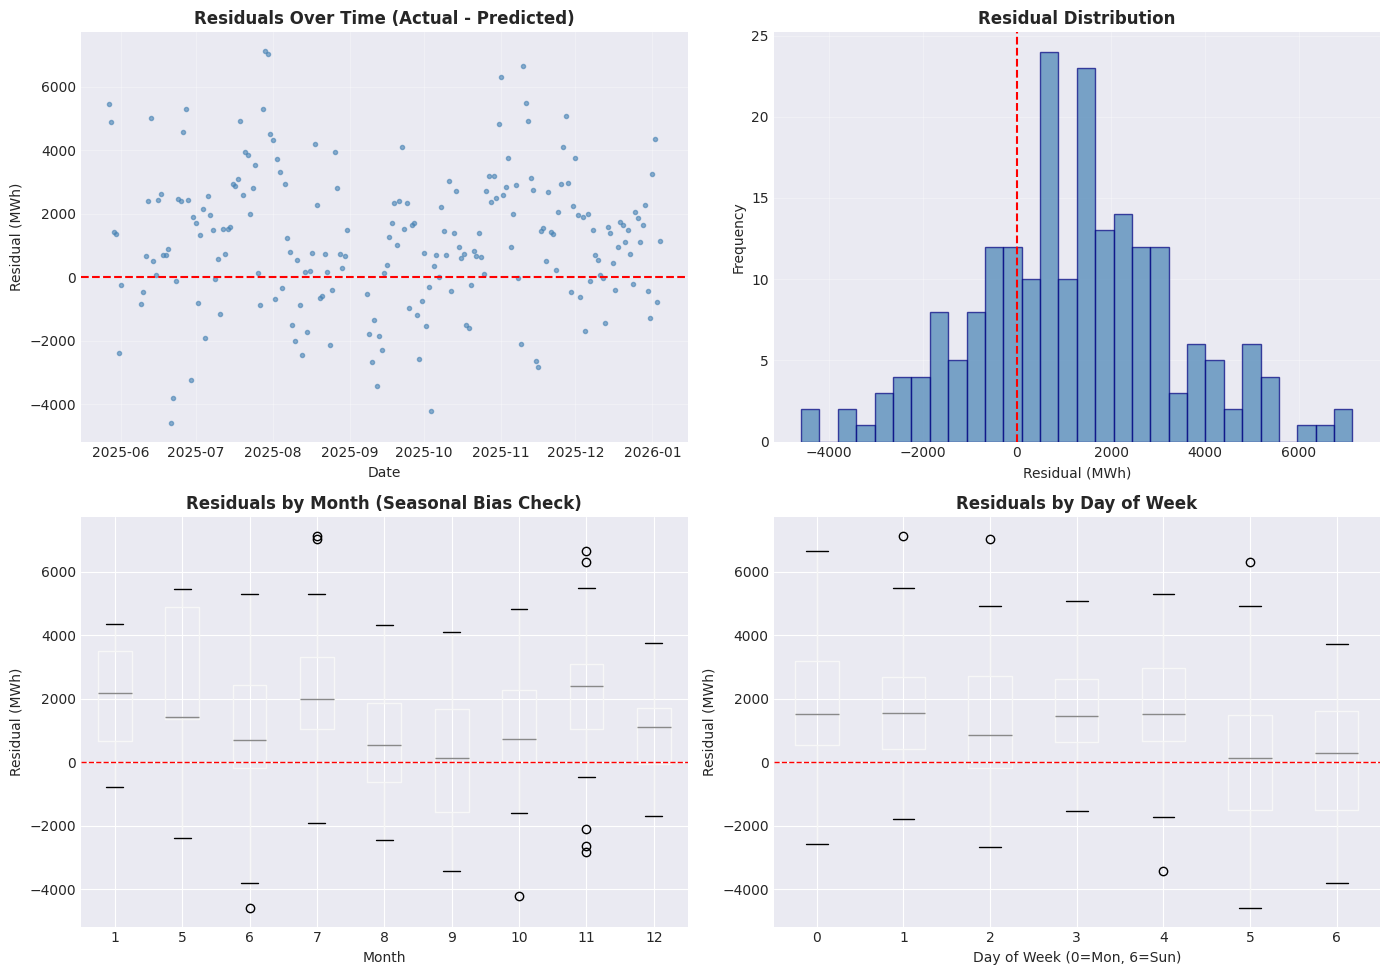

Residual Statistics:
  Mean:    1207.81 MWh (bias!)
  Std:     2145.91 MWh
  Min:    -4592.52 MWh
  Max:     7136.03 MWh
  Median:  1258.27 MWh


In [19]:
# Residual analysis: prediction errors over time
residuals = y_test.values - y_test_pred_rf
test_dates = dates_test.values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(test_dates, residuals, 'o', markersize=3, alpha=0.6, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual (MWh)')
axes[0, 0].set_title('Residuals Over Time (Actual - Predicted)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual distribution
axes[0, 1].hist(residuals, bins=30, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Residual (MWh)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residual Distribution', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals by month — check for seasonal bias
test_months = pd.DatetimeIndex(test_dates).month
residual_df = pd.DataFrame({'month': test_months, 'residual': residuals})
residual_df.boxplot(column='residual', by='month', ax=axes[1, 0])
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Residual (MWh)')
axes[1, 0].set_title('Residuals by Month (Seasonal Bias Check)', fontweight='bold')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.sca(axes[1, 0])
plt.suptitle('')

# 4. Residuals by day of week — check for day-type bias
test_dow = pd.DatetimeIndex(test_dates).dayofweek
residual_df['day_of_week'] = test_dow
residual_df.boxplot(column='residual', by='day_of_week', ax=axes[1, 1])
axes[1, 1].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[1, 1].set_ylabel('Residual (MWh)')
axes[1, 1].set_title('Residuals by Day of Week', fontweight='bold')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.sca(axes[1, 1])
plt.suptitle('')

plt.tight_layout()
plt.show()

# Summary statistics
print("Residual Statistics:")
print(f"  Mean:   {residuals.mean():>8.2f} MWh {'(bias!)' if abs(residuals.mean()) > 50 else '(unbiased ✓)'}")
print(f"  Std:    {residuals.std():>8.2f} MWh")
print(f"  Min:    {residuals.min():>8.2f} MWh")
print(f"  Max:    {residuals.max():>8.2f} MWh")
print(f"  Median: {np.median(residuals):>8.2f} MWh")

## Step 9: Production Prediction Pipeline

### 9.1 Unified Prediction Function (Past/Tomorrow/Future)

In [20]:
def predict_demand(target_date, mode='auto'):
    """
    Unified prediction function for Singapore electricity demand.
    
    Parameters:
    -----------
    target_date : str or datetime
        The date to predict for (format: 'YYYY-MM-DD')
    mode : str
        'past', 'tomorrow', 'future', or 'auto' (auto-detect based on date)
    
    Returns:
    --------
    dict with regression and classification predictions
    """
    
    target_date = pd.to_datetime(target_date)
    # Use dataset end as the knowledge boundary, not wall-clock today.
    # EMA data is a manual download and currently only covers up to 2025,
    # so dates beyond the dataset end are always 'future' predictions.
    dataset_end = df_clean['date'].max()
    today_wallclock = pd.Timestamp.today().normalize()
    
    if mode == 'auto':
        if target_date <= dataset_end:
            mode = 'past'       # date is within the downloaded EMA dataset
        elif target_date <= today_wallclock + timedelta(days=1):
            mode = 'tomorrow'   # beyond dataset but within next-day wall-clock window
        else:
            mode = 'future'     # beyond dataset and beyond tomorrow
    
    print(f"\n{'='*70}")
    print(f"ELECTRICITY DEMAND PREDICTION")
    print(f"{'='*70}")
    print(f"Target Date: {target_date.strftime('%A, %Y-%m-%d')}")
    print(f"Prediction Mode: {mode.upper()}")
    
    if mode == 'past':
        historical_record = df_clean[df_clean['date'] == target_date.normalize()]
        if len(historical_record) == 0:
            print(f"\n✗ Date not found in historical dataset ({df_clean['date'].min()} to {df_clean['date'].max()})")
            return None
        rec = historical_record.iloc[0]
        feature_dict = {col: rec[col] for col in feature_cols}
        actual_demand = rec['demand_mwh']

    elif mode == 'tomorrow':
        data_end = dataset_end
        real_today = today_wallclock
        lag_days = (real_today - data_end).days
        if lag_days > 0:
            print(f"\n⚠ Data gap: dataset ends {data_end.date()} but today is {real_today.date()} ({lag_days} days behind).")
            print(f"  Using last available record as a proxy. For accurate results, update the dataset.")

        # Use last available weather conditions deterministically (no random noise)
        # In production, replace this block with a live Open-Meteo forecast API call
        print(f"\nNote: Using last available weather as proxy (deterministic).")
        print(f"  → In production, connect Open-Meteo forecast API for live weather.")
        today_idx = len(df_clean) - 1
        today_rec = df_clean.iloc[today_idx]
        tomorrow_date = today_wallclock + timedelta(days=1)
        tomorrow_dow = tomorrow_date.dayofweek
        tomorrow_month = tomorrow_date.month
        tomorrow_doy = tomorrow_date.dayofyear
        tomorrow_week = tomorrow_date.isocalendar()[1]

        # Deterministic: use last known weather directly (no random perturbation)
        temp_max = today_rec['temp_max']
        temp_min = today_rec['temp_min']
        temp_mean = today_rec['temp_mean']
        humidity_max = today_rec['humidity_max']
        precipitation = today_rec['precipitation']
        wind_speed = today_rec['wind_speed']
        apparent_temp_max = today_rec['apparent_temp_max']

        feature_dict = {
            'temp_max': temp_max,
            'temp_min': temp_min,
            'temp_mean': temp_mean,
            'humidity_max': humidity_max,
            'precipitation': precipitation,
            'wind_speed': wind_speed,
            'apparent_temp_max': apparent_temp_max,
            'demand_lag_1': today_rec['demand_mwh'],
            'demand_lag_7': df_clean.iloc[today_idx - 7]['demand_mwh'],
            'temp_mean_lag_1': today_rec['temp_mean'],
            'demand_rolling_7': today_rec['demand_rolling_7'],
            'demand_rolling_30': today_rec['demand_rolling_30'],
            'temp_mean_rolling_3': today_rec['temp_mean_rolling_3'],
            'humidity_rolling_3': today_rec['humidity_rolling_3'],
            'is_weekend': 1 if tomorrow_dow >= 5 else 0,
            'is_holiday': 1 if str(tomorrow_date.date()) in sg_holiday_dates else 0,
            'month': tomorrow_month,
            'day_of_year': tomorrow_doy,
            'week_of_year': tomorrow_week,
            'temp_humidity_interaction': temp_mean * humidity_max / 100
        }
        actual_demand = None

    elif mode == 'future':
        days_ahead = (target_date - today_wallclock).days
        if days_ahead > 16:
            print(f"\n✗ Forecast only available up to 16 days ahead (requested {days_ahead} days)")
            return None
        print(f"\nNote: In production, this would fetch Open-Meteo 16-day forecast API")
        print(f"Days ahead: {days_ahead}")
        # Use same-DOY historical climatology (average over matching months) instead of random noise
        # This produces deterministic, repeatable estimates rather than random values each call
        target_month = target_date.month
        same_month_rows = df_clean[df_clean['date'].dt.month == target_month]
        if len(same_month_rows) == 0:
            same_month_rows = df_clean  # fallback: use all data
        today_rec = df_clean.iloc[-1]

        temp_max = same_month_rows['temp_max'].mean()
        temp_min = same_month_rows['temp_min'].mean()
        temp_mean = same_month_rows['temp_mean'].mean()
        humidity_max = same_month_rows['humidity_max'].mean()
        precipitation = same_month_rows['precipitation'].mean()
        wind_speed = same_month_rows['wind_speed'].mean()
        apparent_temp_max = same_month_rows['apparent_temp_max'].mean()
        print(f"  Using climatology from {len(same_month_rows)} historical days in month {target_month}")

        feature_dict = {
            'temp_max': temp_max,
            'temp_min': temp_min,
            'temp_mean': temp_mean,
            'humidity_max': humidity_max,
            'precipitation': precipitation,
            'wind_speed': wind_speed,
            'apparent_temp_max': apparent_temp_max,
            'demand_lag_1': today_rec['demand_rolling_7'],
            'demand_lag_7': df_clean.iloc[-8]['demand_mwh'],
            'temp_mean_lag_1': today_rec['temp_mean'],
            'demand_rolling_7': today_rec['demand_rolling_7'],
            'demand_rolling_30': today_rec['demand_rolling_30'],
            'temp_mean_rolling_3': today_rec['temp_mean_rolling_3'],
            'humidity_rolling_3': today_rec['humidity_rolling_3'],
            'is_weekend': 1 if target_date.dayofweek >= 5 else 0,
            'is_holiday': 1 if str(target_date.date()) in sg_holiday_dates else 0,
            'month': target_date.month,
            'day_of_year': target_date.dayofyear,
            'week_of_year': target_date.isocalendar()[1],
            'temp_humidity_interaction': temp_mean * humidity_max / 100
        }
        actual_demand = None

    else:
        print(f"\n✗ Invalid prediction mode: {mode}")
        return None

    X_pred = pd.DataFrame([feature_dict])
    _reg_model = rf_model
    _cls_model = rf_class
    reg_pred = _reg_model.predict(X_pred)[0]
    class_pred = _cls_model.predict(X_pred)[0]
    class_prob = _cls_model.predict_proba(X_pred)[0]

    result = {
        'date': target_date.strftime('%Y-%m-%d'),
        'mode': mode,
        'regression': {
            'predicted_mwh': round(reg_pred, 2),
            'actual_mwh': round(actual_demand, 2) if actual_demand is not None else None
        },
        'classification': {
            'predicted_level': class_names[class_pred],
            'confidence': round(class_prob[class_pred] * 100, 1),
            'probabilities': {class_names[i]: round(class_prob[i] * 100, 1) for i in range(3)}
        }
    }

    print(f"\n{'-'*70}")
    print(f"PREDICTIONS:")
    print(f"{'-'*70}")
    print(f"\n📊 REGRESSION (Exact Demand):")
    print(f"  Predicted demand: {result['regression']['predicted_mwh']} MWh")
    if result['regression']['actual_mwh'] is not None:
        error = abs(result['regression']['predicted_mwh'] - result['regression']['actual_mwh'])
        error_pct = error / result['regression']['actual_mwh'] * 100
        print(f"  Actual demand:    {result['regression']['actual_mwh']} MWh")
        print(f"  Error:            {error:.0f} MWh ({error_pct:.1f}%)")

    print(f"\n📈 CLASSIFICATION (Demand Level):")
    print(f"  Predicted level:  {result['classification']['predicted_level']}")
    print(f"  Confidence:       {result['classification']['confidence']}%")
    print(f"  Probabilities:    Low={result['classification']['probabilities']['Low']}%, "
          f"Medium={result['classification']['probabilities']['Medium']}%, "
          f"High={result['classification']['probabilities']['High']}%")
    print(f"{'-'*70}\n")

    return result

print("✓ Prediction function defined (deterministic — no random noise)")
print("\nUsage: predict_demand('2025-06-15')  # Past date (within EMA dataset)")
print("       predict_demand('tomorrow')    # Tomorrow")
print("       predict_demand('2025-06-15')  # Future date (up to 16 days)")

✓ Prediction function defined (deterministic — no random noise)

Usage: predict_demand('2025-06-15')  # Past date (within EMA dataset)
       predict_demand('tomorrow')    # Tomorrow
       predict_demand('2025-06-15')  # Future date (up to 16 days)


### 9.2 Demonstration: Make Predictions

In [21]:
# Example 1: Predict for a historical date in training data
print("\n" + "="*70)
print("EXAMPLE 1: Historical Date Prediction")
print("="*70)
# Use a date we know is in the historical range (last available date in training set)
_hist_date = df_clean['date'].iloc[int(len(df_clean) * 0.5)].strftime('%Y-%m-%d')  # midpoint of dataset
result_historical = predict_demand(_hist_date, mode='past')

# Example 2: Predict for a future date
print("\n" + "="*70)
print("EXAMPLE 2: Future Date Prediction (5 days ahead)")
print("="*70)
future_date = (pd.to_datetime('today') + timedelta(days=5)).strftime('%Y-%m-%d')
result_future = predict_demand(future_date, mode='future')

# Example 3: Create predictions for a week ahead
print("\n" + "="*70)
print("EXAMPLE 3: 7-Day Forecast")
print("="*70)
forecast_7day = []
for i in range(1, 8):
    pred_date = (pd.to_datetime('today') + timedelta(days=i)).strftime('%Y-%m-%d')
    result = predict_demand(pred_date, mode='future')
    if result:
        forecast_7day.append(result)

# Display 7-day forecast summary
if forecast_7day:
    print("\n" + "-"*70)
    print("7-DAY FORECAST SUMMARY")
    print("-"*70)
    forecast_df = pd.DataFrame([
        {
            'Date': r['date'],
            'Predicted (MWh)': r['regression']['predicted_mwh'],
            'Level': r['classification']['predicted_level'],
            'Confidence': f"{r['classification']['confidence']}%"
        }
        for r in forecast_7day
    ])
    print(forecast_df.to_string(index=False))
    print("-"*70)


EXAMPLE 1: Historical Date Prediction

ELECTRICITY DEMAND PREDICTION
Target Date: Friday, 2024-07-05
Prediction Mode: PAST

----------------------------------------------------------------------
PREDICTIONS:
----------------------------------------------------------------------

📊 REGRESSION (Exact Demand):
  Predicted demand: 167845.51 MWh
  Actual demand:    167711 MWh
  Error:            135 MWh (0.1%)

📈 CLASSIFICATION (Demand Level):
  Predicted level:  High
  Confidence:       96.9%
  Probabilities:    Low=0.0%, Medium=3.1%, High=96.9%
----------------------------------------------------------------------


EXAMPLE 2: Future Date Prediction (5 days ahead)

ELECTRICITY DEMAND PREDICTION
Target Date: Sunday, 2026-06-21
Prediction Mode: FUTURE

Note: In production, this would fetch Open-Meteo 16-day forecast API
Days ahead: 5
  Using climatology from 83 historical days in month 6

----------------------------------------------------------------------
PREDICTIONS:
------------------

## Summary & Key Results

### Project Completion Checklist

In [23]:
# Determine best models dynamically from computed metrics
best_reg_name  = 'Linear Regression' if lr_test_r2 > rf_test_r2 else 'Random Forest'
best_reg_mae   = lr_test_mae  if lr_test_r2 > rf_test_r2 else rf_test_mae
best_reg_rmse  = lr_test_rmse if lr_test_r2 > rf_test_r2 else rf_test_rmse
best_reg_r2    = lr_test_r2   if lr_test_r2 > rf_test_r2 else rf_test_r2

best_cls_name  = 'Logistic Regression' if lr_class_test_acc > rf_class_test_acc else 'Random Forest'
best_cls_acc   = lr_class_test_acc  if lr_class_test_acc > rf_class_test_acc else rf_class_test_acc
best_cls_f1    = lr_cls_f1          if lr_class_test_acc > rf_class_test_acc else rf_cls_f1
best_cls_preds = y_test_pred_lr_class if lr_class_test_acc > rf_class_test_acc else y_test_pred_rf_class

reg_improvement  = (baseline_mae - best_reg_mae) / baseline_mae * 100
n_train = len(X_train)
n_test  = len(X_test)
n_total = n_train + n_test
n_features = len(feature_cols)
date_min = df_clean['date'].min().strftime('%Y-%m-%d')
date_max = df_clean['date'].max().strftime('%Y-%m-%d')
train_end = X_train.index[-1]
train_end_date = df_clean.loc[train_end, 'date'].strftime('%Y-%m-%d') if train_end in df_clean.index else 'N/A'

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                 SINGAPORE ENERGY DEMAND FORECAST PROJECT                    ║
║                           COMPLETION SUMMARY                                ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATASET
  Source:       EMA half-hourly system demand (manual download) + Open-Meteo weather
  Period:       {date_min} to {date_max}
  Total days:   {n_total}
  Training set: {n_train} days (80%)
  Test set:     {n_test} days (20%)
  Features:     {n_features} engineered features

══════════════════════════════════════════════════════════════════════════════
REGRESSION RESULTS (predicting exact daily MWh)
══════════════════════════════════════════════════════════════════════════════
  Baseline (Lag-1)     MAE: {baseline_mae:>10,.2f} MWh   R2: {baseline_r2:.4f}
  Linear Regression    MAE: {lr_test_mae:>10,.2f} MWh   R2: {lr_test_r2:.4f}
  Random Forest        MAE: {rf_test_mae:>10,.2f} MWh   R2: {rf_test_r2:.4f}

  Best model:   {best_reg_name}
  MAE:          {best_reg_mae:,.2f} MWh  ({best_reg_mae/df_clean['demand_mwh'].mean()*100:.2f}% of mean demand)
  RMSE:         {best_reg_rmse:,.2f} MWh
  R2 Score:     {best_reg_r2:.4f}
  Improvement over baseline: {reg_improvement:.1f}% reduction in MAE

══════════════════════════════════════════════════════════════════════════════
CLASSIFICATION RESULTS (predicting demand level: Low / Medium / High)
══════════════════════════════════════════════════════════════════════════════
  Thresholds (from training set):
    Low:    below {percentile_33:,.0f} MWh
    Medium: {percentile_33:,.0f} - {percentile_67:,.0f} MWh
    High:   above {percentile_67:,.0f} MWh

  Logistic Regression  Accuracy: {lr_class_test_acc:.4f}   Macro F1: {lr_cls_f1:.4f}
  Random Forest        Accuracy: {rf_class_test_acc:.4f}   Macro F1: {rf_cls_f1:.4f}

  Best model:   {best_cls_name}
  Accuracy:     {best_cls_acc:.4f} ({best_cls_acc*100:.1f}% of test days correctly classified)
  Macro F1:     {best_cls_f1:.4f}

══════════════════════════════════════════════════════════════════════════════
PREDICTION PIPELINE
══════════════════════════════════════════════════════════════════════════════
  Mode 1 - Past:    Look up actual weather + demand from dataset
  Mode 2 - Tomorrow: Uses last known weather as proxy (connect Open-Meteo for live data)
  Mode 3 - Future:  Monthly climatology estimate (connect Open-Meteo forecast API)

╔══════════════════════════════════════════════════════════════════════════════╗
║                          NEXT STEPS & EXTENSIONS                            ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. Integrate Real APIs
   - Connect Open-Meteo for live weather (tomorrow mode)
   - Implement 16-day forecast retrieval (future mode)
   - Automate EMA data download when API becomes available

2. Advanced Models
   - LSTM neural network for sequential multi-day patterns
   - Gradient boosting (XGBoost/LightGBM) with more training data (2026+)
   - Ensemble: combine regression + classification outputs

3. Feature Enhancement
   - Singapore school holidays and public events
   - Solar radiation and UV index
   - Industrial load schedules

4. Production Deployment
   - REST API wrapper around predict_demand()
   - Dashboard for daily forecast visualization
   - Automated retraining pipeline when new EMA data is published

╔══════════════════════════════════════════════════════════════════════════════╗
║                           PROJECT DELIVERABLES                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

  Trained Regression Model  : {best_reg_name} (MAE {best_reg_mae:,.0f} MWh, R2 {best_reg_r2:.4f})
  Trained Classification Model: {best_cls_name} (Accuracy {best_cls_acc:.4f}, F1 {best_cls_f1:.4f})
  Feature Scaler            : StandardScaler ({n_features} features)
  Prediction Function       : predict_demand(date, mode) - past / tomorrow / future
  EDA Visualizations        : time series, correlation heatmap, scatter, boxplot
""")



╔══════════════════════════════════════════════════════════════════════════════╗
║                 SINGAPORE ENERGY DEMAND FORECAST PROJECT                    ║
║                           COMPLETION SUMMARY                                ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATASET
  Source:       EMA half-hourly system demand (manual download) + Open-Meteo weather
  Period:       2023-02-01 to 2026-01-04
  Total days:   1041
  Training set: 832 days (80%)
  Test set:     209 days (20%)
  Features:     20 engineered features

══════════════════════════════════════════════════════════════════════════════
REGRESSION RESULTS (predicting exact daily MWh)
══════════════════════════════════════════════════════════════════════════════
  Baseline (Lag-1)     MAE:   4,201.75 MWh   R2: 0.2395
  Linear Regression    MAE:   1,545.62 MWh   R2: 0.9047
  Random Forest        MAE:   1,955.59 MWh   R2: 0.8596

  Best model:   Linear Regression
  MAE:    